# Amazon Sales Analysis — Pandas, NumPy & Matplotlib 

**Dataset:** 100,000 Amazon-style e-commerce orders

This notebook uses simple, step-by-step pandas — mostly straightforward
`groupby` + `plot` patterns, a little bit of NumPy, and basic Matplotlib.
Each step is broken into its own cell so it's easy to follow.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Load the data

Read the CSV into a DataFrame called `df`. We tell pandas that `OrderDate`
is a date column so we can work with months and years later.

In [2]:
df = pd.read_csv('Amazon1.csv', parse_dates=['OrderDate'])

In [3]:
# How many rows and columns do we have?
df.shape

(100000, 20)

In [4]:
# Look at the first 5 rows
df.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


## 2. Basic exploration

Before analyzing, let's just look at what we're working with.

In [5]:
# Column names and data types
df.dtypes

OrderID                     str
OrderDate        datetime64[us]
CustomerID                  str
CustomerName                str
ProductID                   str
ProductName                 str
Category                    str
Brand                       str
Quantity                  int64
UnitPrice               float64
Discount                float64
Tax                     float64
ShippingCost            float64
TotalAmount             float64
PaymentMethod               str
OrderStatus                 str
City                        str
State                       str
Country                     str
SellerID                    str
dtype: object

In [6]:
# Any missing values?
df.isnull().sum()

OrderID          0
OrderDate        0
CustomerID       0
CustomerName     0
ProductID        0
ProductName      0
Category         0
Brand            0
Quantity         0
UnitPrice        0
Discount         0
Tax              0
ShippingCost     0
TotalAmount      0
PaymentMethod    0
OrderStatus      0
City             0
State            0
Country          0
SellerID         0
dtype: int64

In [7]:
# Any duplicate OrderIDs?
df['OrderID'].duplicated().sum()

np.int64(0)

In [8]:
# Quick summary statistics for the numeric columns
df.describe()

,OrderDate,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount
count,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2022-06-30 23:55:49.439999,3.001400,302.905748,0.074226,68.468902,7.406660,918.256479
min,2020-01-01 00:00:00,1.000000,5.000000,0.000000,0.000000,0.000000,4.270000
25%,2021-04-01 00:00:00,2.000000,154.190000,0.000000,15.920000,3.680000,340.890000
50%,2022-07-01 00:00:00,3.000000,303.070000,0.050000,45.250000,7.300000,714.315000
75%,2023-09-29 00:00:00,4.000000,451.500000,0.100000,96.060000,11.150000,1349.765000
max,2024-12-29 00:00:00,5.000000,599.990000,0.300000,538.460000,15.000000,3534.980000
std,NaN,1.413548,171.840797,0.082583,74.131180,4.324057,724.508332


## 3. helper columns

We'll pull the month out of `OrderDate` so we can group sales by month later.

In [9]:
df['Month'] = df['OrderDate'].dt.to_period('M').astype(str)

In [10]:
df[['OrderDate', 'Month']].head()

,OrderDate,Month
0,2023-01-31,2023-01
1,2023-12-30,2023-12
2,2022-05-10,2022-05
3,2023-07-18,2023-07
4,2023-02-04,2023-02


## 4. Which product category generates the most revenue?



In [11]:
revenue_by_category = df.groupby('Category')['TotalAmount'].sum()
revenue_by_category = revenue_by_category.sort_values(ascending=False)
revenue_by_category

Category
Electronics          15584217.18
Sports & Outdoors    15345571.88
Books                15261837.01
Clothing             15253397.50
Toys & Games         15216684.99
Home & Kitchen       15163939.36
Name: TotalAmount, dtype: float64

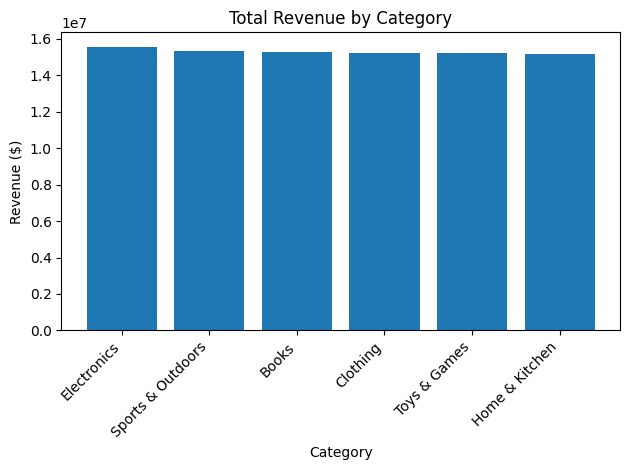

In [12]:
# Plot it as a bar chart
categories = revenue_by_category.index
revenues = revenue_by_category.values

plt.bar(categories, revenues, color='#1f77b4')
plt.title('Total Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('revenue_by_category.png', dpi=150)
plt.show()

## 5. What is the monthly revenue trend?

Same idea as above, but grouping by `Month` instead of `Category`.

In [13]:
monthly_revenue = df.groupby('Month')['TotalAmount'].sum()
monthly_revenue = monthly_revenue.sort_index()
monthly_revenue.head()

Month
2020-01    1637069.40
2020-02    1339388.21
2020-03    1587125.66
2020-04    1588347.29
2020-05    1533834.17
Name: TotalAmount, dtype: float64

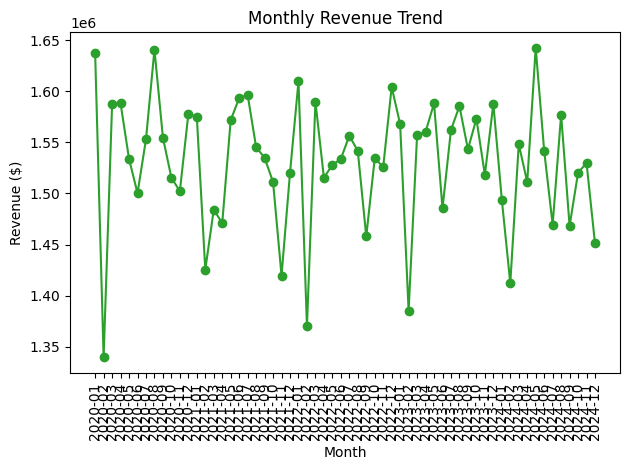

In [14]:
months = monthly_revenue.index
revenue_values = monthly_revenue.values

plt.plot(months, revenue_values, marker='o', color='#2ca02c')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('monthly_revenue_trend.png', dpi=150)
plt.show()

## 6. Which payment method is used most often?

In [15]:
payment_counts = df['PaymentMethod'].value_counts()
payment_counts

PaymentMethod
Credit Card         35038
Debit Card          20024
UPI                 15066
Amazon Pay          15017
Net Banking          9927
Cash on Delivery     4928
Name: count, dtype: int64

In [16]:
# Turn counts into percentages
payment_percent = (payment_counts / payment_counts.sum()) * 100
payment_percent = payment_percent.round(2)
payment_percent

PaymentMethod
Credit Card         35.04
Debit Card          20.02
UPI                 15.07
Amazon Pay          15.02
Net Banking          9.93
Cash on Delivery     4.93
Name: count, dtype: float64

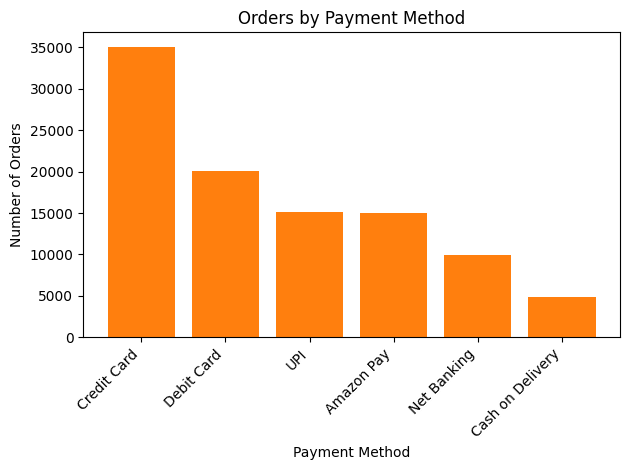

In [17]:
plt.bar(payment_counts.index, payment_counts.values, color='#ff7f0e')
plt.title('Orders by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('payment_method_counts.png', dpi=150)
plt.show()

## 7. What percentage of orders were Cancelled or Returned?

In [18]:
status_counts = df['OrderStatus'].value_counts()
status_counts

OrderStatus
Delivered    74628
Shipped      15192
Pending       4103
Returned      3049
Cancelled     3028
Name: count, dtype: int64

In [19]:
status_percent = (status_counts / status_counts.sum()) * 100
status_percent = status_percent.round(2)
status_percent

OrderStatus
Delivered    74.63
Shipped      15.19
Pending       4.10
Returned      3.05
Cancelled     3.03
Name: count, dtype: float64

In [20]:
# Add up just the Cancelled and Returned percentages
cancelled_pct = status_percent['Cancelled']
returned_pct = status_percent['Returned']
total_problem_pct = cancelled_pct + returned_pct

print('Cancelled:', cancelled_pct, '%')
print('Returned:', returned_pct, '%')
print('Cancelled + Returned combined:', round(total_problem_pct, 2), '%')

Cancelled: 3.03 %
Returned: 3.05 %
Cancelled + Returned combined: 6.08 %


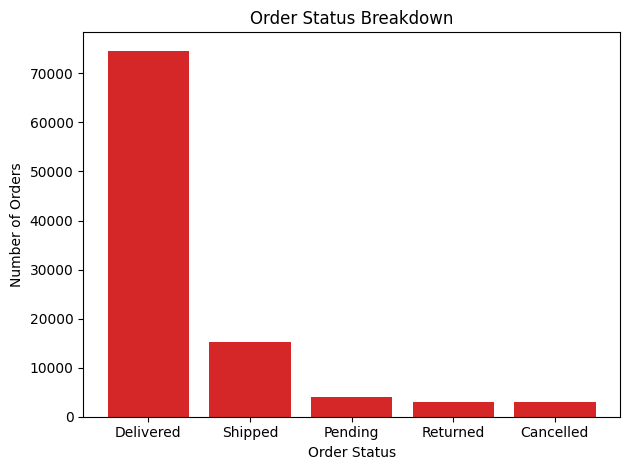

In [21]:
plt.bar(status_counts.index, status_counts.values, color='#d62728')
plt.title('Order Status Breakdown')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('order_status_breakdown.png', dpi=150)
plt.show()

## 8. Which city has the most orders?

In [22]:
top_cities = df['City'].value_counts().head(10)
top_cities

City
Charlotte       5110
Jacksonville    5107
San Jose        5107
Dallas          5105
Los Angeles     5058
Austin          5043
Seattle         5039
Washington      5021
Columbus        5021
Chicago         5020
Name: count, dtype: int64

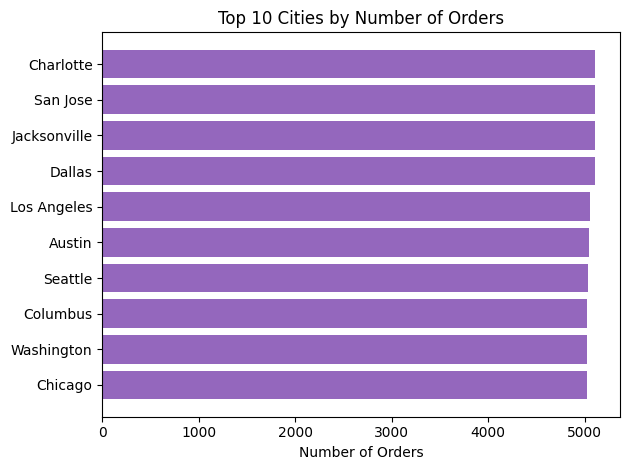

In [23]:
# Sort smallest to largest so the biggest bar is on top in a horizontal chart
top_cities_sorted = top_cities.sort_values()

plt.barh(top_cities_sorted.index, top_cities_sorted.values, color='#9467bd')
plt.title('Top 10 Cities by Number of Orders')
plt.xlabel('Number of Orders')
plt.tight_layout()
plt.savefig('top_10_cities.png', dpi=150)
plt.show()

## 9. A little bit of NumPy: average order value, and rounding


In [24]:
average_order_value = np.mean(df['TotalAmount'])
median_order_value = np.median(df['TotalAmount'])

print('Average order value: $', np.round(average_order_value, 2))
print('Median order value: $', np.round(median_order_value, 2))

Average order value: $ 918.26
Median order value: $ 714.32


## 10. A little bit of NumPy: grouping orders into discount bands

`Discount` is stored as a fraction (0.10 = 10%). We'll use `np.where()`
to label each order as "No Discount", "Low Discount", or "High Discount".

In [25]:
# np.where(condition, value_if_true, value_if_false) — basic version, two outcomes
df['HasDiscount'] = np.where(df['Discount'] > 0, 'Discount Applied', 'No Discount')
df['HasDiscount'].value_counts()

HasDiscount
Discount Applied    59754
No Discount         40246
Name: count, dtype: int64

In [ ]:
# For three categories, we can nest np.where() or use a simple functions

def discount_band(discount):
    if discount == 0:
        return 'No Discount'
    elif discount < 0.20:
        return 'Low (0-20%)'
    else:
        return 'High (20%+)'

df['DiscountBand'] = df['Discount'].apply(discount_band)
df[['Discount', 'DiscountBand']].head()

,Discount,DiscountBand
0,0.00,No Discount
1,0.05,Low (0-20%)
2,0.10,Low (0-20%)
3,0.15,Low (0-20%)
4,0.25,High (20%+)


## 11. Does a higher discount lead to more cancellations?

In [27]:
# For each discount band: how many orders, and how many were cancelled?
discount_group = df.groupby('DiscountBand')

total_orders_per_band = discount_group['OrderID'].count()
cancelled_orders_per_band = discount_group.apply(
    lambda group: (group['OrderStatus'] == 'Cancelled').sum()
)

cancel_summary = pd.DataFrame({
    'TotalOrders': total_orders_per_band,
    'CancelledOrders': cancelled_orders_per_band
})

cancel_summary['CancelRate%'] = np.round(
    (cancel_summary['CancelledOrders'] / cancel_summary['TotalOrders']) * 100, 2
)

cancel_summary

,TotalOrders,CancelledOrders,CancelRate%
DiscountBand,,,
High (20%+),14914,438,2.94
Low (0-20%),44840,1355,3.02
No Discount,40246,1235,3.07


## 12. Top 10 customers by total spend

In [28]:
top_customers = df.groupby(['CustomerID', 'CustomerName'])['TotalAmount'].sum()
top_customers = top_customers.sort_values(ascending=False).head(10)
top_customers

CustomerID  CustomerName 
CUST010696  Pooja Patel      5436.04
CUST035973  Neha Sharma      5124.43
CUST009614  Vikas Mehta      5003.65
CUST018720  Arjun Kapoor     4773.18
CUST022824  Pooja Joshi      4755.48
CUST008882  Sneha Reddy      4730.47
CUST022031  Priya Kapoor     4266.02
CUST031449  Vivaan Kapoor    4253.27
CUST005523  Sahil Patel      4239.18
CUST047013  Arjun Kumar      4222.62
Name: TotalAmount, dtype: float64

## 13. Summary of findings

In [29]:
top_category = revenue_by_category.index[0]
top_category_revenue = revenue_by_category.iloc[0]

top_payment_method = payment_counts.index[0]
top_payment_pct = payment_percent.iloc[0]

top_city = top_cities.index[0]
top_city_orders = top_cities.iloc[0]

best_month = monthly_revenue.idxmax()

print('KEY FINDINGS')
print('--------------------------------------------------')
print(f'Top revenue category: {top_category} (${top_category_revenue:,.2f})')
print(f'Most used payment method: {top_payment_method} ({top_payment_pct}% of orders)')
print(f'City with most orders: {top_city} ({top_city_orders} orders)')
print(f'Highest revenue month: {best_month}')
print(f'Cancelled + Returned orders: {round(total_problem_pct, 2)}% of all orders')
print(f'Average order value: ${np.round(average_order_value, 2)}')

KEY FINDINGS
--------------------------------------------------
Top revenue category: Electronics ($15,584,217.18)
Most used payment method: Credit Card (35.04% of orders)
City with most orders: Charlotte (5110 orders)
Highest revenue month: 2024-05
Cancelled + Returned orders: 6.08% of all orders
Average order value: $918.26
